# Prototyping for the stereo-winds style contrail tracker

In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from datetime import timedelta

from contrailstereo.config import DEFAULT as cfg, SAT_LON
from contrailstereo.data.goes import fetch_pair
from contrailstereo.data.caliop import build_scene_table
from contrailstereo.data.era5 import fetch_era5_winds
from contrailstereo.geometry import apparent_surface_latlon
from contrailstereo.core.fields import make_sampler, hp_km
from contrailstereo.core.retrieve import load_scene, run_scene

In [3]:
NC_PATH = "/Users/lewisclark/Documents/python_work/anticyclonic/data/goes_caliop_contrail_collocations.nc"
scenes, prof_df = build_scene_table(NC_PATH)

In [4]:
row = scenes.iloc[8]
t0 = row.time.floor("s").to_pydatetime()

In [5]:
# snapshot mode
sd = load_scene(row, prof_df, cfg)
rec, pr, third = run_scene(sd, cfg)
if isinstance(third, dict):                      # new extras
    extras = third
else:                                            # old tuple
    g0, g1, Hq_, rmax_ = third
    extras = dict(glat=g0, glon=g1, Hq=Hq_, rmax=rmax_)

glat, glon = extras["glat"], extras["glon"]
px = ((glat[-1, 0] - glat[0, 0]) * 111.0 / glat.shape[0],
      (glon[0, -1] - glon[0, 0]) * 111.0
      * np.cos(np.deg2rad(glat.mean())) / glat.shape[1])
sig = (cfg.hp_sigma_km / px[0], cfg.hp_sigma_km / px[1])

tmpl_mask = np.isfinite(extras["Hq"]) & (extras["rmax"] > 0.6)
print(f"snapshot h = {rec['h_local']:.2f}  qc={rec['qc']}  "
      f"template {tmpl_mask.sum()} px  px={px[0]:.2f}x{px[1]:.2f} km")

# multi-frame fetch
DTS = [-20, -10, 0, 10, 20]                      # minutes
frames, times = {}, {}
for k, dm in enumerate(DTS):
    tk = t0 + timedelta(minutes=dm)
    for sat in (16, 17):
        f, _ = fetch_pair(tk, sat, cfg)
        frames[(sat, k)] = make_sampler(f[14], f[15])
        times[(sat, k)] = np.datetime64(f[14].t.values)

REF = (16, 2)                                    # G16 @ t0
ref = hp_km(frames[REF](glat, glon), sig)

snapshot h = 12.69  qc=ok  template 14821 px  px=1.00x1.00 km


In [6]:
def measure_displacement(ref, img, mask, max_px=12, center=(0, 0)):
    """2-D shift of img vs ref over the template mask, searched within
    +-max_px of `center` (a first-guess shift in px). Returns (di, dj,
    r_peak, saturated): saturated=True means the peak sat on the search
    boundary -- treat the observation as unreliable or re-centre."""
    ci, cj = int(round(center[0])), int(round(center[1]))
    n = 2 * max_px + 1
    best = np.full((n, n), np.nan)
    for a in range(n):
        for b in range(n):
            di, dj = ci + a - max_px, cj + b - max_px
            sh = np.roll(np.roll(img, di, 0), dj, 1)
            m = mask & np.isfinite(ref) & np.isfinite(sh)
            if m.sum() < 200:
                continue
            best[a, b] = np.corrcoef(ref[m], sh[m])[0, 1]
    ij = np.unravel_index(np.nanargmax(np.nan_to_num(best, nan=-9)),
                          best.shape)
    r_pk = float(best[ij])
    saturated = ij[0] in (0, n - 1) or ij[1] in (0, n - 1)

    def refine1d(tri):
        if tri.shape[0] != 3 or not np.isfinite(tri).all():
            return 0.0
        a_, b_, c_ = tri
        den = a_ - 2 * b_ + c_
        return float(np.clip(0.5 * (a_ - c_) / den, -1, 1)) if den != 0 else 0.0

    di = ci + ij[0] - max_px
    dj = cj + ij[1] - max_px
    if not saturated:
        di += refine1d(best[ij[0]-1:ij[0]+2, ij[1]])
        dj += refine1d(best[ij[0], ij[1]-1:ij[1]+2])
    return di, dj, r_pk, saturated

In [7]:
winds = fetch_era5_winds(t0, float(row.lat), float(row.lon), cfg)
print(f"snapshot h: {rec['h_local']:.2f}   CALIOP: {row.top_km:.2f}")
#print(f"ERA5 at fitted h: u={winds[0](x[0]):+.1f}  v={winds[1](x[0]):+.1f}")

snapshot h: 12.69   CALIOP: 13.04


In [8]:
# ============ cell 3: geometry vectors + measured disparities + joint fit ===

# ---- parallax-per-km geometry vectors -------------------------------------
# g_vec(sat): how far [km, (dlat_km, dlon_km)] a cloud's apparent position
# moves per km of height, seen from `sat` at the scene centre. Computed by
# differencing the exact projection at h=1 km vs h=0 (linear-in-h to <1%
# over the cruise band -- tested in test_displacement_linear_in_h).
def g_vec(sat):
    la1, lo1 = apparent_surface_latlon(row.lat, row.lon, 1000.0, SAT_LON[sat])
    return np.array([(float(la1) - row.lat) * 111.0,
                     (float(lo1) - row.lon) * 111.0
                     * np.cos(np.deg2rad(row.lat))])

G = {16: g_vec(16), 17: g_vec(17)}
print(f"g16 = ({G[16][0]:+.2f}, {G[16][1]:+.2f}) km/km   "
      f"g17 = ({G[17][0]:+.2f}, {G[17][1]:+.2f}) km/km")
# sanity: predominantly zonal, opposite lon signs, |g| ~ tan(VZA) ~ 1-2

# ---- ERA5 first guess ------------------------------------------------------
winds = fetch_era5_winds(t0, float(row.lat), float(row.lon), cfg)
h0 = rec["h_local"]

# ---- measure disparities, build the linear system --------------------------
# model per non-reference image (s, k), relative to REF = (16, t0):
#   d_km = (G_s - G_16) * h  +  V * dt          (V in km/s, dt in s)
# unknowns x = [h (km), u (km/s), v (km/s)]
rows_A, rows_b, wts, meta = [], [], [], []
for (sat, k), samp in frames.items():
    if (sat, k) == REF:
        continue
    img = hp_km(samp(glat, glon), sig)
    dt_s = float((times[(sat, k)] - times[REF]) / np.timedelta64(1, "s"))

    guess_km = (G[sat] - G[16]) * h0 + np.array(
        [winds[1](h0), winds[0](h0)]) * dt_s / 1e3     # [v->lat, u->lon]
    center = (guess_km[0] / px[0], guess_km[1] / px[1])

    di, dj, r_pk, sat_flag = measure_displacement(
        ref, img, tmpl_mask, max_px=12, center=center)
    if sat_flag:
        print(f"sat {sat} k={k}: SATURATED -- skipped")
        continue

    d_km = np.array([di * px[0], dj * px[1]])          # observed [km]
    dG = G[sat] - G[16]
    # lat-row:  dG_lat * h + v * dt
    rows_A.append([dG[0], 0.0, dt_s]); rows_b.append(d_km[0])
    # lon-row:  dG_lon * h + u * dt
    rows_A.append([dG[1], dt_s, 0.0]); rows_b.append(d_km[1])
    wts += [max(r_pk, 0.05)] * 2
    meta.append(dict(sat=sat, k=k, dt_s=dt_s, r=r_pk,
                     d_lat=d_km[0], d_lon=d_km[1]))
    print(f"sat {sat} k={k}: d=({d_km[0]:+.2f},{d_km[1]:+.2f}) km  "
          f"dt={dt_s:+5.0f}s  r={r_pk:.2f}")

# ---- weighted least squares + covariance -----------------------------------
A = np.asarray(rows_A, float)
b = np.asarray(rows_b, float)
w = np.sqrt(np.asarray(wts, float))
x, *_ = np.linalg.lstsq(A * w[:, None], b * w, rcond=None)

resid = A @ x - b
dof = max(len(b) - 3, 1)
s2 = float(np.sum((resid * w) ** 2) / np.sum(w ** 2) * len(b) / dof)
cov = np.linalg.inv((A * w[:, None]).T @ (A * w[:, None])) * s2

h_fit = x[0]
u_fit, v_fit = x[1] * 1e3, x[2] * 1e3               # km/s -> m/s
sh, su, sv = (np.sqrt(cov[0, 0]),
              np.sqrt(cov[1, 1]) * 1e3, np.sqrt(cov[2, 2]) * 1e3)

print(f"\njoint fit:  h = {h_fit:5.2f} +- {sh:.2f} km")
print(f"            u = {u_fit:+5.1f} +- {su:.1f} m/s   "
      f"v = {v_fit:+5.1f} +- {sv:.1f} m/s")
print(f"residual RMS = {np.sqrt(np.mean(resid**2)):.2f} km over {len(b)} eqns")
print(f"\nvalidation: snapshot h = {h0:.2f}   CALIOP = {row.top_km:.2f}")
print(f"            ERA5 at h_fit: u = {winds[0](h_fit):+.1f}  "
      f"v = {winds[1](h_fit):+.1f} m/s")

g16 = (+0.88, -1.32) km/km   g17 = (+0.83, +0.61) km/km
sat 16 k=0: d=(-29.93,-56.75) km  dt=-1200s  r=0.14
sat 17 k=0: d=(-34.83,-24.03) km  dt=-1197s  r=0.12
sat 16 k=1: d=(-13.16,-22.97) km  dt= -600s  r=0.11
sat 17 k=1: SATURATED -- skipped
sat 17 k=2: d=(-8.45,+12.83) km  dt=   +3s  r=0.18
sat 16 k=3: d=(+10.85,+24.78) km  dt= +600s  r=0.10
sat 17 k=3: SATURATED -- skipped
sat 16 k=4: d=(+39.07,+51.87) km  dt=+1200s  r=0.15
sat 17 k=4: d=(+41.38,+72.12) km  dt=+1203s  r=0.10

joint fit:  h =  9.97 +- 4.83 km
            u = +42.5 +- 6.5 m/s   v = +29.2 +- 6.5 m/s
residual RMS = 5.08 km over 14 eqns

validation: snapshot h = 12.69   CALIOP = 13.04
            ERA5 at h_fit: u = +42.0  v = +23.6 m/s


In [9]:
def project_frame(sat, k, hkm, u, v):
    """Frame (sat, k) reprojected to true-position coordinates at t0:
    undo advection over (t_k - t0) at (u, v), then undo parallax at hkm.
    EVERY frame gets this, including the reference (dt=0 there, so only
    the parallax part -- but that part is ~20 km and non-optional)."""
    dt = float((times[(sat, k)] - times[REF]) / np.timedelta64(1, "s"))
    gla = glat + v * dt / 111.0e3
    glo = glon + u * dt / (111.0e3 * np.cos(np.deg2rad(glat)))
    ala, alo = apparent_surface_latlon(gla, glo, hkm * 1e3, SAT_LON[sat])
    return hp_km(frames[(sat, k)](ala, alo), sig)


def stack_corr(hkm, u, v):
    ref_p = project_frame(*REF, hkm, u, v)       # h-dependent; dt=0
    rs = []
    for key in frames:
        if key == REF:
            continue
        B = project_frame(*key, hkm, u, v)
        m = tmpl_mask & np.isfinite(ref_p) & np.isfinite(B)
        if m.sum() > 200:
            rs.append(np.corrcoef(ref_p[m], B[m])[0, 1])
    return float(np.mean(rs))

In [9]:
OUT = "/Users/lewisclark/Documents/python_work/stereo/outputs/tracking_mini.csv"
H_SCAN = np.arange(8.0, 15.01, 0.25)



{'scene': 8, 'status': 'ok', 'caliop': 13.04, 'h_snap': 12.69, 'r_snap': 0.77, 'h_track': 12.89, 'u_track': 41.58, 'v_track': 24.95, 'r_stack': 0.68, 'r_cross': 0.7, 'r_same': 0.66, 'u_era5': 44.43, 'v_era5': 25.8, 'n_frames': 10, 'qc_snap': 'ok'}
{'scene': 5, 'status': 'ok', 'caliop': 11.68, 'h_snap': 11.11, 'r_snap': 0.75, 'h_track': 11.25, 'u_track': 44.2, 'v_track': 28.28, 'r_stack': 0.66, 'r_cross': 0.64, 'r_same': 0.69, 'u_era5': 44.87, 'v_era5': 28.51, 'n_frames': 10, 'qc_snap': 'ok'}
{'scene': 12, 'status': 'ok', 'caliop': 10.47, 'h_snap': 10.23, 'r_snap': 0.7, 'h_track': 10.28, 'u_track': 7.87, 'v_track': 19.05, 'r_stack': 0.6, 'r_cross': 0.6, 'r_same': 0.6, 'u_era5': 6.32, 'v_era5': 18.57, 'n_frames': 10, 'qc_snap': 'ok'}
{'scene': 24, 'status': 'ok', 'caliop': 11.41, 'h_snap': 10.71, 'r_snap': 0.52, 'h_track': 10.97, 'u_track': 3.17, 'v_track': 4.01, 'r_stack': 0.4, 'r_cross': 0.43, 'r_same': 0.35, 'u_era5': 10.9, 'v_era5': 6.76, 'n_frames': 10, 'qc_snap': 'ok'}
{'scene': 41

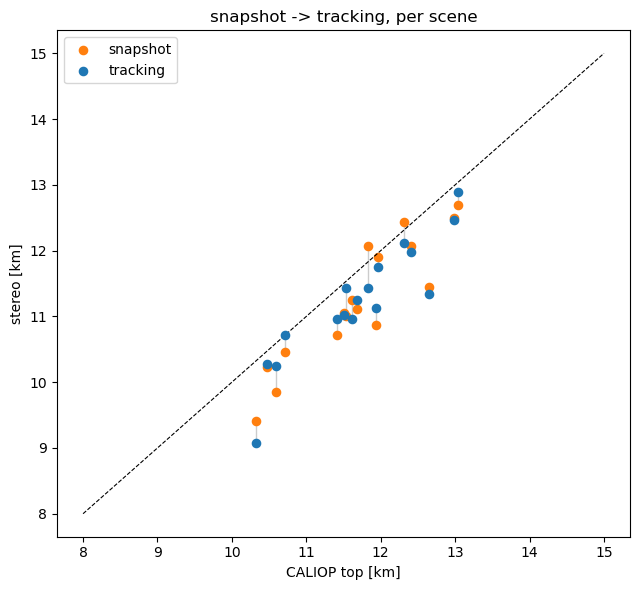

In [10]:
# ================= tracking mini-validation: 20 scenes =====================
import os, traceback
import numpy as np, pandas as pd
from datetime import timedelta
from contrailstereo.config import DEFAULT as cfg, SAT_LON
from contrailstereo.data.goes import fetch_pair
from contrailstereo.data.era5 import fetch_era5_winds
from contrailstereo.geometry import apparent_surface_latlon
from contrailstereo.core.fields import make_sampler, hp_km
from contrailstereo.core.retrieve import load_scene, run_scene
from contrailstereo.core.peaks import refine_peak

DTS = [-20, -10, 0, 10, 20]          # minutes
H_SCAN = np.arange(8.0, 15.01, 0.25)
DV = np.arange(-6, 6.1, 2.0)         # V-scan half-grid [m/s]
OUT = "/Users/lewisclark/Documents/python_work/stereo/outputs/tracking_mini.csv"

def track_scene(si):
    from scipy.ndimage import label as cc_label
    row = scenes.iloc[si]
    t0 = row.time.floor("s").to_pydatetime()

    # ---- snapshot: grid, reference h, quality map (per scene!) -----------
    sd = load_scene(row, prof_df, cfg)
    rec, pr, extras = run_scene(sd, cfg)
    glat, glon = extras["glat"], extras["glon"]
    px = ((glat[-1, 0] - glat[0, 0]) * 111.0 / glat.shape[0],
          (glon[0, -1] - glon[0, 0]) * 111.0
          * np.cos(np.deg2rad(glat.mean())) / glat.shape[1])
    sig = (cfg.hp_sigma_km / px[0], cfg.hp_sigma_km / px[1])

    # ---- blob-filtered template ------------------------------------------
    if extras["Hq"] is None:
        return dict(scene=si, status="no_template", h_snap=rec["h_local"])
    lab, ncc = cc_label(np.isfinite(extras["Hq"]) & (extras["rmax"] > 0.6))
    sizes = np.bincount(lab.ravel())[1:] if ncc else np.array([])
    tmpl = np.isin(lab, np.where(sizes >= 25)[0] + 1)
    if tmpl.sum() < 300 or (sizes.max() if sizes.size else 0) < 50:
        return dict(scene=si, status="no_template", h_snap=rec["h_local"])

    # ---- frames -----------------------------------------------------------
    frames, times = {}, {}
    for k, dm in enumerate(DTS):
        for sat in (16, 17):
            try:
                f, _ = fetch_pair(t0 + timedelta(minutes=dm), sat, cfg)
                frames[(sat, k)] = make_sampler(f[14], f[15])
                times[(sat, k)] = np.datetime64(f[14].t.values)
            except Exception:
                pass
    REF = (16, DTS.index(0))
    if REF not in frames or len(frames) < 6:
        return dict(scene=si, status="frames_missing", h_snap=rec["h_local"])

    def project(key, hkm, u, v):
        dt = float((times[key] - times[REF]) / np.timedelta64(1, "s"))
        gla = glat + v * dt / 111.0e3
        glo = glon + u * dt / (111.0e3 * np.cos(np.deg2rad(glat)))
        ala, alo = apparent_surface_latlon(gla, glo, hkm * 1e3,
                                           SAT_LON[key[0]])
        return hp_km(frames[key](ala, alo), sig), dt

    def stack_corr(hkm, u, v):
        ref_p, _ = project(REF, hkm, u, v)
        rc, rs_ = [], []
        for key in frames:
            if key == REF:
                continue
            B, dt = project(key, hkm, u, v)
            m = tmpl & np.isfinite(ref_p) & np.isfinite(B)
            if m.sum() > 200:
                r = np.corrcoef(ref_p[m], B[m])[0, 1]
                (rc if key[0] != REF[0] else rs_).append(r)
        return (2 * np.mean(rc) + np.mean(rs_)) / 3 if rc and rs_ else np.nan

    # ---- winds + ERA5-anchored alternation --------------------------------
    winds = fetch_era5_winds(t0, float(row.lat), float(row.lon), cfg)
    if winds is None:
        return dict(scene=si, status="no_era5", h_snap=rec["h_local"])
    h0 = rec["h_local"] if np.isfinite(rec["h_local"]) else 11.0
    u_e, v_e = winds[0](h0), winds[1](h0)
    u0, v0 = u_e, v_e
    SIG_V = 3.0
    for _ in range(2):
        curve = np.array([stack_corr(h, u0, v0) for h in H_SCAN])
        h_best, _, _ = refine_peak(H_SCAN, curve,
                                   H_SCAN[int(np.nanargmax(curve))])
        uu, vv = np.meshgrid(u_e + DV, v_e + DV)
        pen = 0.005 * ((uu - u_e) ** 2 + (vv - v_e) ** 2) / SIG_V ** 2
        surf = np.array([[stack_corr(h_best, uu[a, b], vv[a, b])
                          for b in range(uu.shape[1])]
                         for a in range(uu.shape[0])]) - pen
        a, b = np.unravel_index(np.nanargmax(surf), surf.shape)
        u0, v0 = float(uu[a, b]), float(vv[a, b])

    # ---- final evaluation: split scores + per-frame detail ----------------
    ref_p, _ = project(REF, h_best, u0, v0)
    per_frame, rc, rs_ = [], [], []
    for key in frames:
        if key == REF:
            continue
        B, dt = project(key, h_best, u0, v0)
        m = tmpl & np.isfinite(ref_p) & np.isfinite(B)
        if m.sum() > 200:
            r = float(np.corrcoef(ref_p[m], B[m])[0, 1])
            per_frame.append((key[0], dt, r))
            (rc if key[0] != REF[0] else rs_).append(r)
    r_cross = float(np.mean(rc)) if rc else np.nan
    r_same = float(np.mean(rs_)) if rs_ else np.nan
    r_stack = float(np.mean(rc + rs_)) if (rc or rs_) else np.nan

    return dict(scene=si, status="ok", caliop=float(row.top_km),
                h_snap=float(rec["h_local"]), r_snap=float(rec["r_local"]),
                h_track=float(h_best), u_track=u0, v_track=v0,
                r_stack=r_stack, r_cross=r_cross, r_same=r_same,
                u_era5=float(winds[0](h_best)), v_era5=float(winds[1](h_best)),
                n_frames=len(frames), qc_snap=rec["qc"],
                curve=curve.tolist(), per_frame=per_frame)

MINI20 = [0, 8, 5, 12, 24, 41, 46, 87, 25, 7, 17, 50, 60, 66, 100,
          108, 110, 122, 133, 146]
rows = []
done = set()
if os.path.exists(OUT):
    prev = pd.read_csv(OUT); rows = prev.to_dict("records")
    done = set(prev.scene)
for si in MINI20:
    if si in done:
        continue
    try:
        r = track_scene(si)
    except Exception as e:
        print(f"scene {si} FAILED: {e}"); traceback.print_exc(limit=2)
        continue
    rows.append({k: v for k, v in r.items()
                 if k not in ("curve", "per_frame")})
    np.save(f"/Users/lewisclark/Documents/python_work/stereo/outputs/track_diag_{si:04d}.npy",
            {k: r.get(k) for k in ("curve", "per_frame")},
            allow_pickle=True)
    pd.DataFrame(rows).to_csv(OUT, index=False)
    print({k: (round(v, 2) if isinstance(v, float) else v)
           for k, v in rows[-1].items()})

# ---- comparison ------------------------------------------------------------
t = pd.DataFrame(rows)
ok = t[(t.status == "ok") & np.isfinite(t.h_snap)]
es, et = ok.h_snap - ok.caliop, ok.h_track - ok.caliop
print(f"\nn={len(ok)}  snapshot: bias {es.mean():+.2f} scatter {es.std():.2f}"
      f"   tracking: bias {et.mean():+.2f} scatter {et.std():.2f}")
print(f"tracking closer to CALIOP on {(et.abs() < es.abs()).sum()}/{len(ok)}"
      f"   wind vs ERA5: u {np.sqrt(((ok.u_track-ok.u_era5)**2).mean()):.1f}"
      f"  v {np.sqrt(((ok.v_track-ok.v_era5)**2).mean()):.1f} m/s RMS")

import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(6.5, 6))
for _, r_ in ok.iterrows():
    ax.plot([r_.caliop, r_.caliop], [r_.h_snap, r_.h_track],
            "-", color="0.8", lw=1, zorder=1)
ax.scatter(ok.caliop, ok.h_snap, s=35, c="C1", label="snapshot", zorder=2)
ax.scatter(ok.caliop, ok.h_track, s=35, c="C0", label="tracking", zorder=3)
ax.plot([8, 15], [8, 15], "k--", lw=0.8)
ax.set_xlabel("CALIOP top [km]"); ax.set_ylabel("stereo [km]")
ax.set_title("snapshot -> tracking, per scene"); ax.legend()
plt.tight_layout(); plt.show()

subset                   n snap RMSEc track RMSEc  improved  wind RMS
all                     17      0.374       0.356    8/17         4.2
r_stack > 0.4           15      0.363       0.372    7/15         3.5

gated paired mean d|err| = -0.036 +- 0.061 km  (n=15)

biggest improvements:
 scene  caliop  e_snap  e_track  d_abs  r_stack  r_t0  persist_10  wind_err qc_snap
    46   11.53   -0.52    -0.09  -0.43     0.49   NaN         NaN      1.99      ok
     7   10.59   -0.75    -0.35  -0.40     0.66   NaN         NaN      3.44      ok
    24   11.41   -0.70    -0.44  -0.25     0.40   NaN         NaN      8.20      ok

biggest degradations (the improvement targets):
 scene  caliop  e_snap  e_track  d_abs  r_stack  r_t0  persist_10  wind_err qc_snap
    87   10.32   -0.91    -1.24   0.33     0.42   NaN         NaN      9.28      ok
    50   11.62   -0.38    -0.66   0.28     0.57   NaN         NaN      4.65      ok
    17   11.83    0.23    -0.41   0.17     0.46   NaN         NaN      2.01

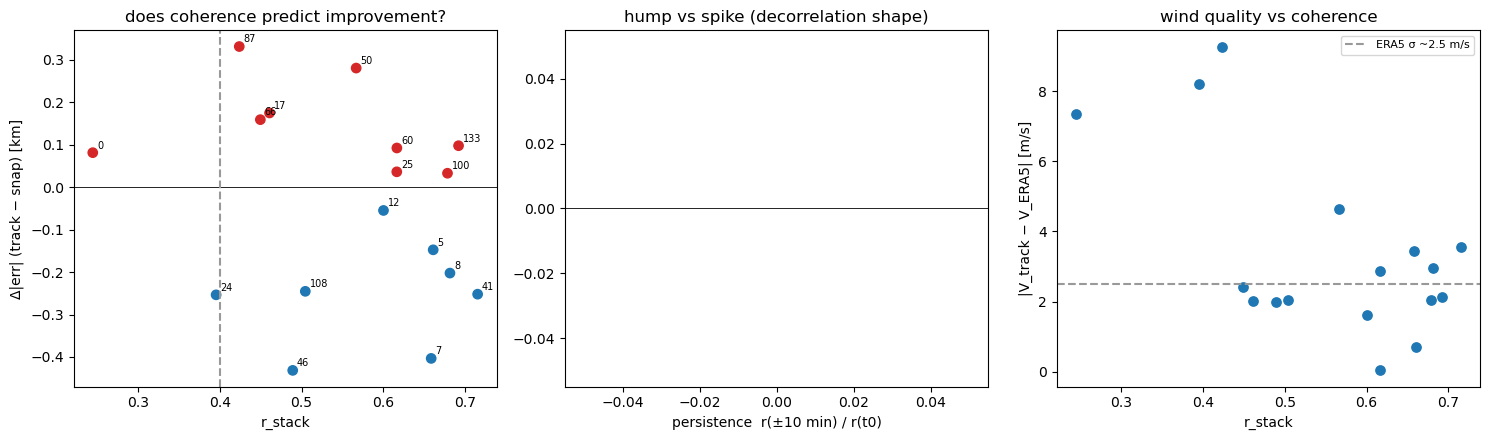


corr(r_stack, d_abs)     = -0.24
corr(persist_10, d_abs)  = +nan
corr(r_stack, wind_err)  = -0.61


In [13]:
# ============ tracking mini-validation: full diagnostics ====================
import numpy as np, pandas as pd, matplotlib.pyplot as plt

t = pd.read_csv("/Users/lewisclark/Documents/python_work/stereo/outputs/tracking_mini.csv")
ok = t[(t.status == "ok") & np.isfinite(t.h_snap)].copy()

# ---- enrich with the decorrelation shape from the per-scene diag files ----
def decorr_stats(si):
    try:
        d = np.load(f"outputs/track_diag_{si:04d}.npy",
                    allow_pickle=True).item()
        pf = pd.DataFrame(d["per_frame"], columns=["sat", "dt", "r"])
        r0 = pf[pf.dt.abs() < 300].r.mean()          # the t0 pair
        r10 = pf[(pf.dt.abs() > 300) & (pf.dt.abs() < 900)].r.mean()
        r20 = pf[pf.dt.abs() > 900].r.mean()
        return pd.Series(dict(r_t0=r0, persist_10=r10 / r0 if r0 > 0 else np.nan,
                              persist_20=r20 / r0 if r0 > 0 else np.nan))
    except FileNotFoundError:
        return pd.Series(dict(r_t0=np.nan, persist_10=np.nan,
                              persist_20=np.nan))

ok = ok.join(ok.scene.apply(decorr_stats))
ok["e_snap"] = ok.h_snap - ok.caliop
ok["e_track"] = ok.h_track - ok.caliop
ok["d_abs"] = ok.e_track.abs() - ok.e_snap.abs()     # negative = improved
ok["wind_err"] = np.hypot(ok.u_track - ok.u_era5, ok.v_track - ok.v_era5)

def corr_rmse(e):
    e = np.asarray(e, float)
    return np.sqrt(((e - e.mean()) ** 2).mean())

# ---- the r_stack-gated split (THE test) -----------------------------------
print(f"{'subset':22s} {'n':>3} {'snap RMSEc':>10} {'track RMSEc':>11} "
      f"{'improved':>9} {'wind RMS':>9}")
for name, sub in [("all", ok),
                  ("r_stack > 0.4", ok[ok.r_stack > 0.4]),
                  ("r_stack <= 0.4", ok[ok.r_stack <= 0.4])]:
    if len(sub) < 3:
        continue
    print(f"{name:22s} {len(sub):3d} {corr_rmse(sub.e_snap):10.3f} "
          f"{corr_rmse(sub.e_track):11.3f} "
          f"{(sub.d_abs < 0).sum():>4d}/{len(sub):<4d} "
          f"{np.sqrt((sub.wind_err**2).mean()):9.1f}")

# paired effect on the gated set, with its (small-n) uncertainty
g = ok[ok.r_stack > 0.4]
if len(g) >= 4:
    d = g.d_abs
    print(f"\ngated paired mean d|err| = {d.mean():+.3f} "
          f"+- {d.std() / np.sqrt(len(d)):.3f} km  (n={len(d)})")

# ---- case-study queue ------------------------------------------------------
cols = ["scene", "caliop", "e_snap", "e_track", "d_abs", "r_stack",
        "r_t0", "persist_10", "wind_err", "qc_snap"]
print("\nbiggest improvements:")
print(ok.nsmallest(3, "d_abs")[cols].round(2).to_string(index=False))
print("\nbiggest degradations (the improvement targets):")
print(ok.nlargest(3, "d_abs")[cols].round(2).to_string(index=False))

# ---- three-panel figure ----------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

axes[0].scatter(ok.r_stack, ok.d_abs, s=45,
                c=np.where(ok.d_abs < 0, "C0", "C3"))
axes[0].axhline(0, color="k", lw=0.6)
axes[0].axvline(0.4, color="0.6", ls="--")
axes[0].set_xlabel("r_stack"); axes[0].set_ylabel("Δ|err| (track − snap) [km]")
axes[0].set_title("does coherence predict improvement?")
for _, r_ in ok.iterrows():
    axes[0].annotate(int(r_.scene), (r_.r_stack, r_.d_abs), fontsize=7,
                     xytext=(3, 3), textcoords="offset points")

axes[1].scatter(ok.persist_10, ok.d_abs, s=45,
                c=np.where(ok.d_abs < 0, "C0", "C3"))
axes[1].axhline(0, color="k", lw=0.6)
axes[1].set_xlabel("persistence  r(±10 min) / r(t0)")
axes[1].set_title("hump vs spike (decorrelation shape)")

axes[2].scatter(ok.r_stack, ok.wind_err, s=45, c="C0")
axes[2].axhline(2.5, color="0.6", ls="--", label="ERA5 σ ~2.5 m/s")
axes[2].set_xlabel("r_stack"); axes[2].set_ylabel("|V_track − V_ERA5| [m/s]")
axes[2].set_title("wind quality vs coherence"); axes[2].legend(fontsize=8)
plt.tight_layout(); plt.show()

print(f"\ncorr(r_stack, d_abs)     = {ok.r_stack.corr(ok.d_abs):+.2f}")
print(f"corr(persist_10, d_abs)  = {ok.persist_10.corr(ok.d_abs):+.2f}")
print(f"corr(r_stack, wind_err)  = {ok.r_stack.corr(ok.wind_err):+.2f}")

In [ ]:
# ---- regenerate per-frame diagnostics from the fitted (h, u, v) -----------
t = pd.read_csv("/Users/lewisclark/Documents/python_work/stereo/outputs/tracking_mini.csv")
for _, r_ in t[t.status == "ok"].iterrows():
    si = int(r_.scene)
    P = prepare_tracking(si)
    project, tmpl, REF = P["project"], P["tmpl"], P["REF"]
    ref_p, _ = project(REF, r_.h_track, r_.u_track, r_.v_track)
    det = []
    for key in P["frames"]:
        if key == REF:
            continue
        B, dt = project(key, r_.h_track, r_.u_track, r_.v_track)
        m = tmpl & np.isfinite(ref_p) & np.isfinite(B)
        if m.sum() > 200:
            det.append((key[0], dt, float(np.corrcoef(ref_p[m], B[m])[0, 1])))
    np.save(f"/Users/lewisclark/Documents/python_work/stereo/outputs/track_diag_{si:04d}.npy",
            dict(per_frame=det), allow_pickle=True)
    print(si, len(det))

0 9
8 9
5 9
12 9
24 9
41 9
46 9
87 9
25 9
7 9
17 9
50 9
60 9
66 9
100 9
108 9
133 9


: 

: 

: 

: 

In [10]:
def prepare_tracking(si):
    """Rebuild the tracking machinery for one scene (shared by
    track_scene and diagnose_tracking -- and the shape core/track.py
    will adopt). Cache-warm after the loop: fast, no new downloads.

    Returns dict: frames, times, REF, project, tmpl, glat, glon, sig,
    row, rec.
    """
    row = scenes.iloc[si]
    t0 = row.time.floor("s").to_pydatetime()

    sd = load_scene(row, prof_df, cfg)
    rec, pr, extras = run_scene(sd, cfg)
    glat, glon = extras["glat"], extras["glon"]
    px = ((glat[-1, 0] - glat[0, 0]) * 111.0 / glat.shape[0],
          (glon[0, -1] - glon[0, 0]) * 111.0
          * np.cos(np.deg2rad(glat.mean())) / glat.shape[1])
    sig = (cfg.hp_sigma_km / px[0], cfg.hp_sigma_km / px[1])
    tmpl = np.isfinite(extras["Hq"]) & (extras["rmax"] > 0.6)

    frames, times = {}, {}
    for k, dm in enumerate(DTS):
        for sat in (16, 17):
            try:
                f, _ = fetch_pair(t0 + timedelta(minutes=dm), sat, cfg)
                frames[(sat, k)] = make_sampler(f[14], f[15])
                times[(sat, k)] = np.datetime64(f[14].t.values)
            except Exception:
                pass
    REF = (16, DTS.index(0))

    def project(key, hkm, u, v):
        dt = float((times[key] - times[REF]) / np.timedelta64(1, "s"))
        gla = glat + v * dt / 111.0e3
        glo = glon + u * dt / (111.0e3 * np.cos(np.deg2rad(glat)))
        ala, alo = apparent_surface_latlon(gla, glo, hkm * 1e3,
                                           SAT_LON[key[0]])
        return hp_km(frames[key](ala, alo), sig), dt

    return dict(frames=frames, times=times, REF=REF, project=project,
                tmpl=tmpl, glat=glat, glon=glon, sig=sig, row=row, rec=rec)

In [ ]:
def diagnose_tracking(si):
    """Everything the tracker did on one scene, images + curves."""
    row = scenes.iloc[si]
    res = pd.read_csv(OUT).set_index("scene").loc[si]
    d = np.load(f"/Users/lewisclark/Documents/python_work/stereo/outputs/track_diag_{si:04d}.npy",
                allow_pickle=True).item()
    P = prepare_tracking(si)
    project, tmpl = P["project"], P["tmpl"]
    glat, glon = P["glat"], P["glon"]

    h, u, v = res.h_track, res.u_track, res.v_track
    SHOW = [(16, 0), (16, 2), (17, 2), (16, 4)]      # -20, t0 both, +20

    fig = plt.figure(figsize=(15, 11))
    gs = fig.add_gridspec(3, 4, height_ratios=[1, 1, 0.9])
    ext = [glon.min(), glon.max(), glat.min(), glat.max()]

    for c, key in enumerate(SHOW):
        A, dt = project(key, h, u, v)                # row 1: at the fit
        ax = fig.add_subplot(gs[0, c])
        ax.imshow(A, origin="lower", cmap="Greys_r", vmin=-1.5, vmax=1.5,
                  extent=ext)
        ax.contour(glon, glat, tmpl, levels=[0.5], colors="cyan",
                   linewidths=0.6)
        ax.set_title(f"G{key[0]} dt={dt:+.0f}s  @fit", fontsize=8)
        ax.set_xticks([]); ax.set_yticks([])

        B, _ = project(key, h, 0.0, 0.0)             # row 2: no wind
        ax = fig.add_subplot(gs[1, c])
        ax.imshow(B, origin="lower", cmap="Greys_r", vmin=-1.5, vmax=1.5,
                  extent=ext)
        ax.contour(glon, glat, tmpl, levels=[0.5], colors="cyan",
                   linewidths=0.6)
        ax.set_title("same, V=0 (motion visible)", fontsize=8)
        ax.set_xticks([]); ax.set_yticks([])

    # row 3: the three graphs
    ax = fig.add_subplot(gs[2, 0:2])
    ax.plot(H_SCAN, d["curve"], "C0-", label="stack r (at fitted V)")
    ax.axvline(res.caliop, color="r", ls="--", label="CALIOP")
    ax.axvline(res.h_snap, color="C1", ls=":", label="snapshot h")
    ax.axvline(h, color="C0", ls=":", label="tracking h")
    ax.set_xlabel("assumed height [km]"); ax.set_ylabel("stack r")
    ax.legend(fontsize=7)

    ax = fig.add_subplot(gs[2, 2])
    pf = pd.DataFrame(d["per_frame"], columns=["sat", "dt", "r"])
    for s_, c_ in [(16, "C0"), (17, "C3")]:
        p = pf[pf.sat == s_].sort_values("dt")
        ax.plot(p.dt / 60, p.r, "o-", color=c_, label=f"G{s_}")
    ax.set_xlabel("dt [min]"); ax.set_ylabel("frame r vs ref")
    ax.set_title("template decorrelation", fontsize=9)
    ax.legend(fontsize=7)

    ax = fig.add_subplot(gs[2, 3])
    ax.arrow(0, 0, res.u_era5, res.v_era5, color="0.5", width=0.4,
             length_includes_head=True, label="ERA5")
    ax.arrow(0, 0, res.u_track, res.v_track, color="C0", width=0.4,
             length_includes_head=True, label="tracked")
    lim = 1.3 * max(abs(res.u_track), abs(res.v_track), 5)
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
    ax.axhline(0, color="0.85", lw=0.5); ax.axvline(0, color="0.85", lw=0.5)
    ax.set_xlabel("u [m/s]"); ax.set_ylabel("v [m/s]")
    ax.set_title("wind: tracked vs ERA5", fontsize=9)
    fig.suptitle(f"scene {si}: h={h:.2f} (CALIOP {res.caliop:.2f})  "
                 f"u={u:+.1f} v={v:+.1f}  r={res.r_stack:.2f}", fontsize=11)
    plt.tight_layout(); plt.show()

KeyError: 'curve'

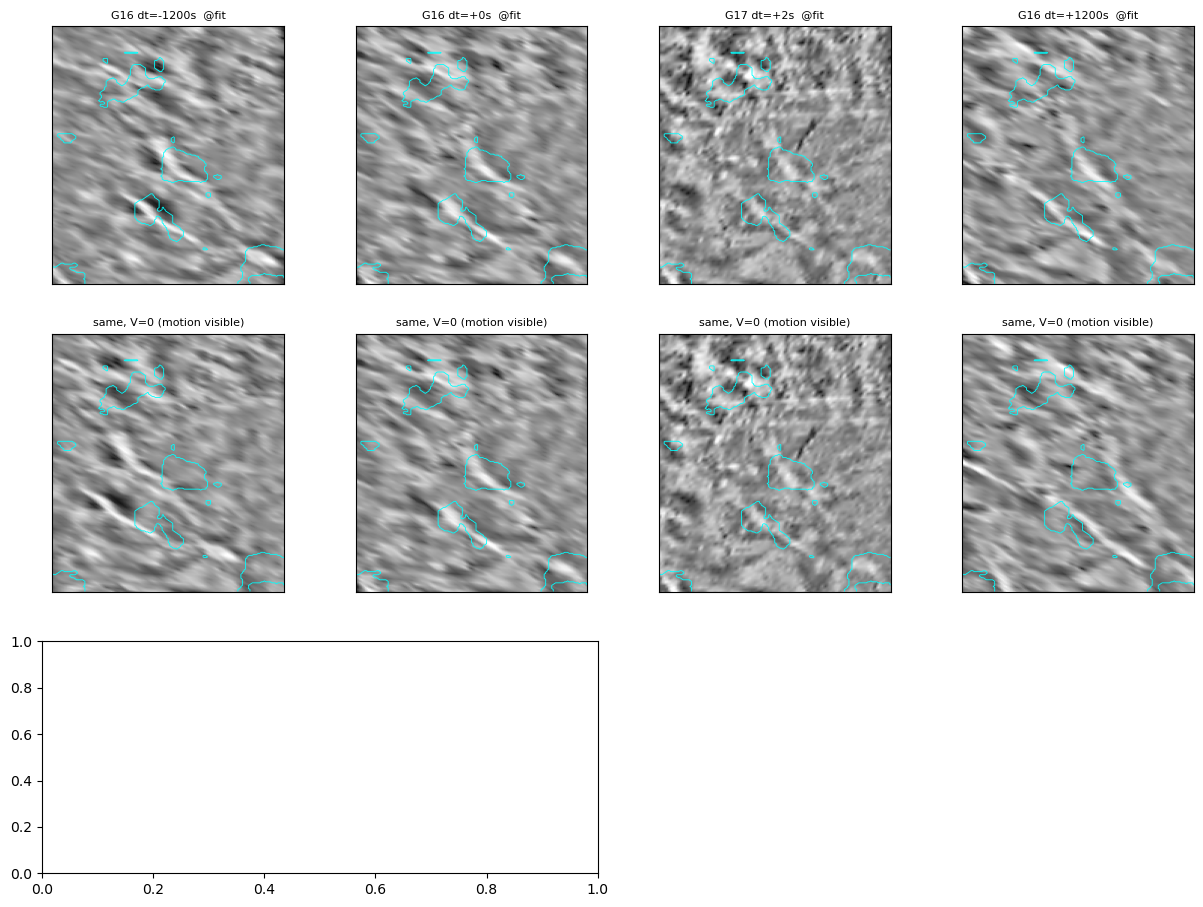

In [ ]:
diagnose_tracking(87)